# Experiment 6
## Simple Neural Network Concept using Python

**Name:** Ayush Gupta  
**SAP ID:** 500125537  
**Batch:** B7  
**Course:** Algorithms for Intelligent Systems and Robotics Lab

### Aim
To understand the basic concept of an artificial neural network and to implement one from scratch in python using only numpy, to train it on the logic gates and on a non linearly separable dataset, and to compare the result with a standard library implementation.

### Theory

**The neuron.** A neuron takes some inputs, multiplies each of them with a weight, adds a bias and then passes the result through an activation function.

$$z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b \qquad a = f(z)$$

The weights decide how important each input is and the bias shifts the decision. Both of them are learnt from the data, nothing is fixed by hand.

**Activation function.** Without an activation function the whole network is only a chain of multiplications and additions, which is again a straight line, so the network cannot learn anything more than a linear model. Here the sigmoid is used

$$f(z) = \frac{1}{1 + e^{-z}} \qquad f'(z) = f(z)\,(1 - f(z))$$

It squeezes any number into the range 0 to 1, so the output can be read as a probability, and its derivative is very easy to write in terms of the function itself which is useful in backpropagation.

**Loss function.** The loss tells how wrong the prediction is. For the logic gates the mean squared error is used and for the classification dataset the binary cross entropy is used

$$L = -\frac{1}{m}\sum \Big[ y \log(\hat{y}) + (1-y)\log(1-\hat{y}) \Big]$$

**Backpropagation and gradient descent.** Training means changing the weights so that the loss becomes small. Backpropagation applies the chain rule of derivatives from the output layer back to the input layer to find how much every weight contributed to the error, and gradient descent then moves each weight in the opposite direction of its gradient

$$w = w - \eta \frac{\partial L}{\partial w}$$

where $\eta$ is the learning rate.

**Why a hidden layer is needed.** A single neuron can only draw one straight line, so it can solve AND and OR but it cannot solve XOR. Adding a hidden layer lets the network bend the boundary, and this is the whole point of the experiment.

### 1. The activation function
Plotting the sigmoid and its derivative first, because both of them are needed in the forward and the backward pass.

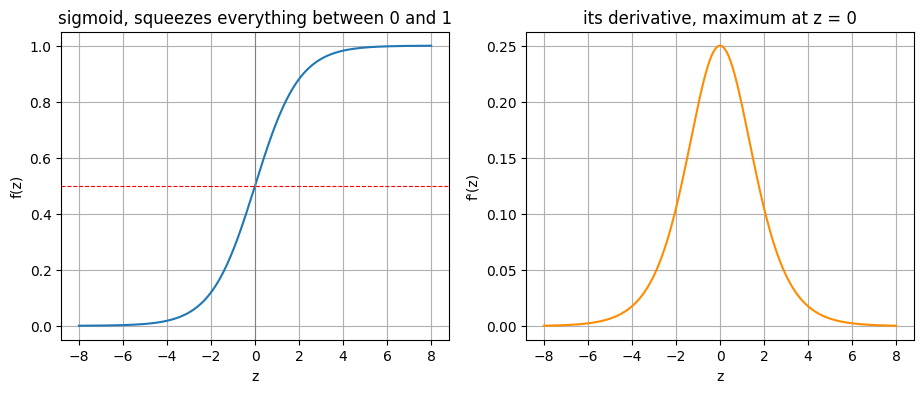

sigmoid(0) = 0.5
sigmoid(5) = 0.9933  sigmoid(-5) = 0.0067


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    # a is the output of sigmoid, not z
    return a * (1 - a)

z = np.linspace(-8, 8, 300)
a = sigmoid(z)

plt.figure(figsize=(11,4))

plt.subplot(1,2,1)
plt.plot(z, a)
plt.axhline(0.5, color='red', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.title("sigmoid, squeezes everything between 0 and 1")
plt.xlabel("z"); plt.ylabel("f(z)"); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(z, sigmoid_derivative(a), color='darkorange')
plt.title("its derivative, maximum at z = 0")
plt.xlabel("z"); plt.ylabel("f'(z)"); plt.grid(True)

plt.show()

print("sigmoid(0) =", sigmoid(0))
print("sigmoid(5) =", round(sigmoid(5), 4), " sigmoid(-5) =", round(sigmoid(-5), 4))

The derivative is largest near z = 0 and almost zero when z is very large or very small. That is the reason a neuron whose output is already close to 0 or 1 learns very slowly, its gradient has almost died.

### 2. One neuron doing a forward pass
Doing it by hand once, with fixed weights, so that the calculation is clear before any training is started.

In [2]:
x = np.array([1, 0])          # one input sample
w = np.array([0.5, -0.6])     # weights chosen by hand
b = 0.1                       # bias

z = np.dot(w, x) + b
a = sigmoid(z)

print("inputs  :", x)
print("weights :", w, " bias :", b)
print("z = w.x + b =", round(z, 4))
print("output a = sigmoid(z) =", round(a, 4))
print("class predicted :", 1 if a > 0.5 else 0)

inputs  : [1 0]
weights : [ 0.5 -0.6]  bias : 0.1
z = w.x + b = 0.6
output a = sigmoid(z) = 0.6457
class predicted : 1


### 3. Training a single neuron on the logic gates
Now the weights are not chosen by hand, they are learnt. The neuron is trained on AND and on OR using gradient descent.

In [3]:
X = np.array([[0,0], [0,1], [1,0], [1,1]], dtype=float)

y_and = np.array([0, 0, 0, 1], dtype=float)
y_or  = np.array([0, 1, 1, 1], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float)

print("inputs :")
print(X)
print()
print("AND :", y_and.astype(int))
print("OR  :", y_or.astype(int))
print("XOR :", y_xor.astype(int))

inputs :
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

AND : [0 0 0 1]
OR  : [0 1 1 1]
XOR : [0 1 1 0]


In [4]:
def train_single_neuron(X, y, lr=0.5, epochs=5000, seed=1):
    rng = np.random.default_rng(seed)
    w = rng.normal(0, 0.5, X.shape[1])
    b = 0.0
    history = []

    for e in range(epochs):
        # forward
        a = sigmoid(X @ w + b)

        # loss
        loss = np.mean((a - y)**2)
        history.append(loss)

        # backward, derivative of mse through the sigmoid
        delta = (a - y) * sigmoid_derivative(a) * 2 / len(y)

        # update
        w = w - lr * (X.T @ delta)
        b = b - lr * delta.sum()

    return w, b, history


def predict_neuron(X, w, b):
    return (sigmoid(X @ w + b) > 0.5).astype(int)

In [5]:
for name, target in [("AND", y_and), ("OR", y_or), ("XOR", y_xor)]:
    w, b, hist = train_single_neuron(X, target)
    pred = predict_neuron(X, w, b)
    acc = (pred == target).mean()
    print(name.ljust(4), ": predicted", pred, " expected", target.astype(int),
          " accuracy", acc, " final loss", round(hist[-1], 4))

AND  : predicted [0 0 0 1]  expected [0 0 0 1]  accuracy 1.0  final loss 0.0021
OR   : predicted [0 1 1 1]  expected [0 1 1 1]  accuracy 1.0  final loss 0.0011
XOR  : predicted [0 0 0 0]  expected [0 1 1 0]  accuracy 0.5  final loss 0.25


AND and OR are learnt perfectly but **XOR fails completely**, the accuracy is only 0.5 and the loss gets stuck at 0.25 which means the neuron simply gives 0.5 for every input, it has given up.

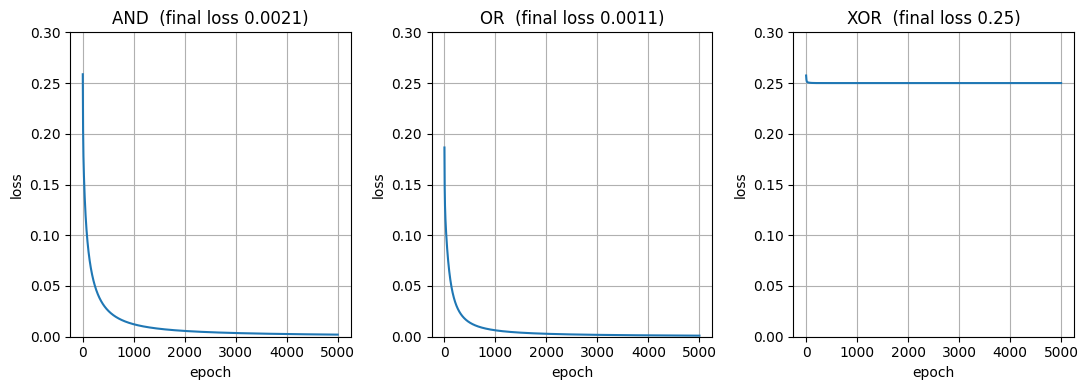

In [6]:
plt.figure(figsize=(11,4))

for i, (name, target) in enumerate([("AND", y_and), ("OR", y_or), ("XOR", y_xor)]):
    w, b, hist = train_single_neuron(X, target)
    plt.subplot(1,3,i+1)
    plt.plot(hist)
    plt.title(name + "  (final loss " + str(round(hist[-1],4)) + ")")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.grid(True)
    plt.ylim(0, 0.3)

plt.tight_layout()
plt.show()

### 4. Why XOR fails
A single neuron can only draw one straight line. For AND and OR a line can be drawn which keeps the 0s on one side and the 1s on the other side, but for XOR no such single line exists, the two classes sit on the opposite corners.

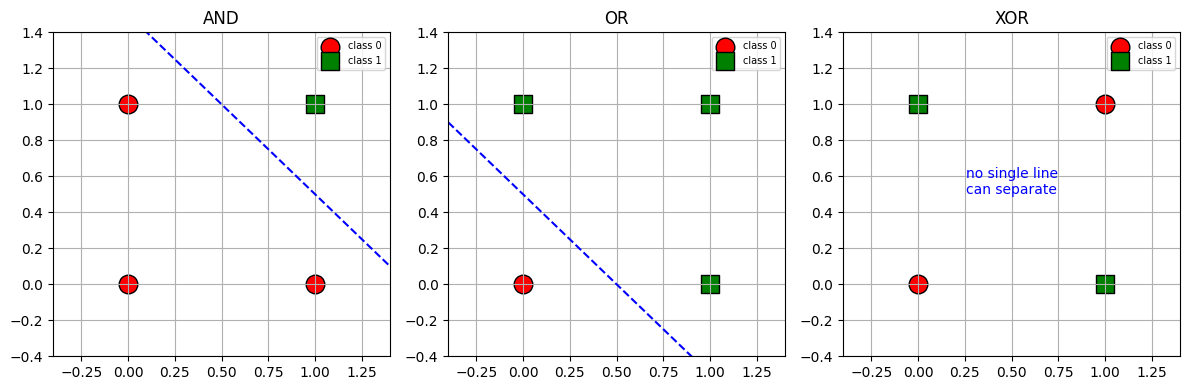

In [7]:
plt.figure(figsize=(12,4))

for i, (name, target) in enumerate([("AND", y_and), ("OR", y_or), ("XOR", y_xor)]):
    plt.subplot(1,3,i+1)
    for cls, marker, colour in [(0, 'o', 'red'), (1, 's', 'green')]:
        pts = X[target == cls]
        plt.scatter(pts[:,0], pts[:,1], marker=marker, s=180, c=colour,
                    edgecolors='black', label="class " + str(cls))
    if name == "AND":
        xx = np.linspace(-0.4, 1.4, 10); plt.plot(xx, 1.5 - xx, 'b--')
    if name == "OR":
        xx = np.linspace(-0.4, 1.4, 10); plt.plot(xx, 0.5 - xx, 'b--')
    if name == "XOR":
        plt.text(0.5, 0.5, "no single line\ncan separate", ha='center', color='blue')
    plt.title(name)
    plt.xlim(-0.4, 1.4); plt.ylim(-0.4, 1.4)
    plt.legend(fontsize=7); plt.grid(True)

plt.tight_layout()
plt.show()

This is exactly the limitation which stopped the research on neural networks for many years, and the solution is to put one more layer of neurons in between.

### 5. Neural network with a hidden layer, written from scratch
The network is 2 inputs, then a hidden layer of a few sigmoid neurons, then 1 output neuron. Everything is written with numpy only, there is no library doing the learning.

The weights are kept in a dictionary so that they can be passed around between the functions.

Before writing the code, this is the network being built. Two inputs, one hidden layer of four sigmoid neurons and one output neuron, which is written as a 2-4-1 network.

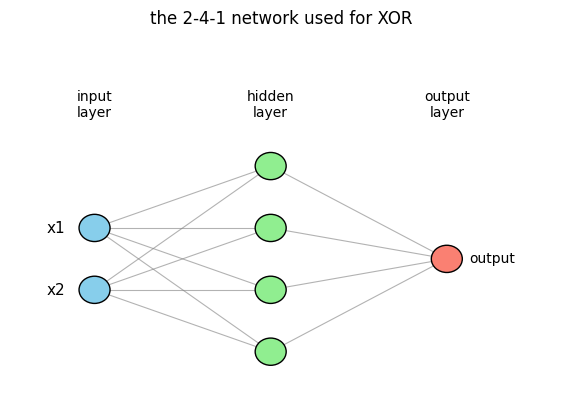

weights to learn :
  W1 : 2 x 4 = 8  and b1 : 4
  W2 : 4 x 1 = 4  and b2 : 1
  total parameters : 17


In [8]:
def draw_network(layer_sizes, title="network structure"):
    fig, ax = plt.subplots(figsize=(7,4.5))
    v_gap, h_gap = 1.0, 2.5

    positions = []
    for l, n in enumerate(layer_sizes):
        # top to bottom, so that x1 comes first
        ys = np.linspace((n-1)*v_gap/2, -(n-1)*v_gap/2, n)
        positions.append([(l*h_gap, y) for y in ys])

    for l in range(len(layer_sizes)-1):
        for (x1, y1) in positions[l]:
            for (x2, y2) in positions[l+1]:
                ax.plot([x1, x2], [y1, y2], color='gray', linewidth=0.8, alpha=0.6, zorder=1)

    colours = ['skyblue', 'lightgreen', 'salmon']
    for l, layer in enumerate(positions):
        for i, (x, y) in enumerate(layer):
            ax.add_patch(plt.Circle((x, y), 0.22, color=colours[l % 3], ec='black', zorder=2))
            if l == 0:
                ax.text(x-0.55, y, "x" + str(i+1), ha='center', va='center', fontsize=11)
            if l == len(positions)-1:
                ax.text(x+0.65, y, "output", ha='center', va='center', fontsize=10)

    top = max(y for layer in positions for (x, y) in layer)
    names = ["input\nlayer", "hidden\nlayer", "output\nlayer"]
    for l in range(len(positions)):
        ax.text(l*h_gap, top + 0.75, names[l], ha='center', va='bottom', fontsize=10)

    ax.set_xlim(-1.2, (len(layer_sizes)-1)*h_gap + 1.5)
    ax.set_ylim(-2.2, top + 1.9)
    ax.axis('off')
    ax.set_title(title, pad=18)
    plt.show()

draw_network([2, 4, 1], title="the 2-4-1 network used for XOR")

print("weights to learn :")
print("  W1 : 2 x 4 =", 2*4, " and b1 :", 4)
print("  W2 : 4 x 1 =", 4*1, " and b2 :", 1)
print("  total parameters :", 2*4 + 4 + 4*1 + 1)

In [9]:
def init_network(n_input, n_hidden, n_output=1, seed=1):
    rng = np.random.default_rng(seed)
    net = {}
    # small random values, if all weights start equal every neuron learns the same thing
    net["W1"] = rng.normal(0, 1, (n_input, n_hidden))
    net["b1"] = np.zeros(n_hidden)
    net["W2"] = rng.normal(0, 1, (n_hidden, n_output))
    net["b2"] = np.zeros(n_output)
    return net


def forward(net, X):
    Z1 = X @ net["W1"] + net["b1"]
    A1 = sigmoid(Z1)                    # hidden layer output
    Z2 = A1 @ net["W2"] + net["b2"]
    A2 = sigmoid(Z2)                    # final output
    return A1, A2


net = init_network(2, 4)
A1, A2 = forward(net, X)
print("hidden layer output shape :", A1.shape)
print("final output shape        :", A2.shape)
print()
print("output before any training :")
print(np.round(A2.ravel(), 3))

hidden layer output shape : (4, 4)
final output shape        : (4, 1)

output before any training :
[0.65  0.69  0.634 0.669]


Before training the output is almost the same for every input, the network knows nothing. Now the backward pass.

For the output layer, $\delta_2 = (A_2 - y) \cdot A_2 (1 - A_2)$ and for the hidden layer the error is pushed back through the weights, $\delta_1 = (\delta_2 W_2^T) \cdot A_1 (1 - A_1)$.

In [10]:
def backward(net, X, y, A1, A2, lr):
    m = len(y)
    Y = y.reshape(-1, 1)

    # output layer error
    d2 = (A2 - Y) * sigmoid_derivative(A2) * 2 / m

    # hidden layer error, the error is sent back through W2
    d1 = (d2 @ net["W2"].T) * sigmoid_derivative(A1)

    # gradient descent update
    net["W2"] = net["W2"] - lr * (A1.T @ d2)
    net["b2"] = net["b2"] - lr * d2.sum(axis=0)
    net["W1"] = net["W1"] - lr * (X.T @ d1)
    net["b1"] = net["b1"] - lr * d1.sum(axis=0)

    return net


def train_network(X, y, n_hidden=4, lr=0.5, epochs=8000, seed=1):
    net = init_network(X.shape[1], n_hidden, seed=seed)
    history = []

    for e in range(epochs):
        A1, A2 = forward(net, X)
        loss = np.mean((A2 - y.reshape(-1,1))**2)
        history.append(loss)
        net = backward(net, X, y, A1, A2, lr)

    return net, history

### 6. Solving XOR with the hidden layer

In [11]:
net, history = train_network(X, y_xor, n_hidden=4, lr=0.5, epochs=8000)

A1, A2 = forward(net, X)
pred = (A2.ravel() > 0.5).astype(int)

print("input      network output   predicted   expected")
for i in range(4):
    print(X[i], "     ", round(A2.ravel()[i], 4), "        ", pred[i], "          ", int(y_xor[i]))

print()
print("accuracy   :", (pred == y_xor).mean())
print("final loss :", round(history[-1], 6))

input      network output   predicted   expected
[0. 0.]       0.0222          0            0
[0. 1.]       0.9719          1            1
[1. 0.]       0.9738          1            1
[1. 1.]       0.0342          0            0

accuracy   : 1.0
final loss : 0.000786


The same problem which a single neuron could not solve at all is now solved perfectly. The outputs are very close to 0 and 1, not sitting at 0.5 any more.

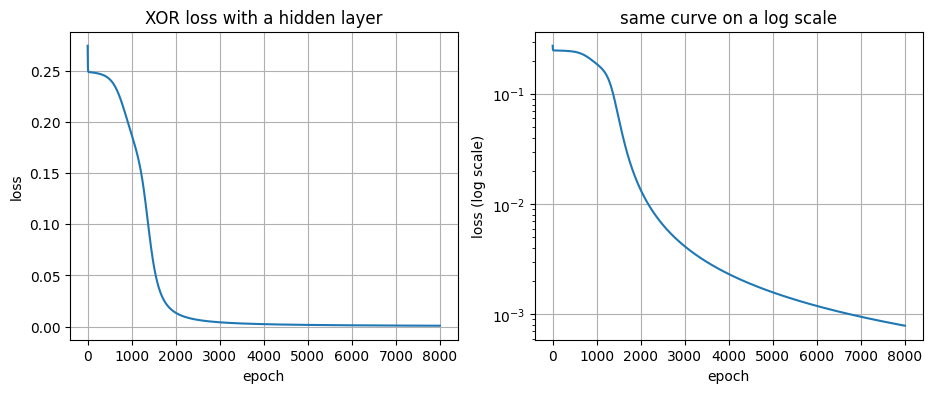

In [12]:
plt.figure(figsize=(11,4))

plt.subplot(1,2,1)
plt.plot(history)
plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("XOR loss with a hidden layer")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history)
plt.yscale("log")
plt.xlabel("epoch"); plt.ylabel("loss (log scale)")
plt.title("same curve on a log scale")
plt.grid(True)

plt.show()

The loss stays almost flat for the first thousand epochs and then falls suddenly. This is normal for XOR, the network first has to arrange the hidden neurons in a useful way and only after that it can reduce the error.

### 7. What the network actually learnt
The decision boundary is drawn by asking the trained network for its output at every point of a fine grid.

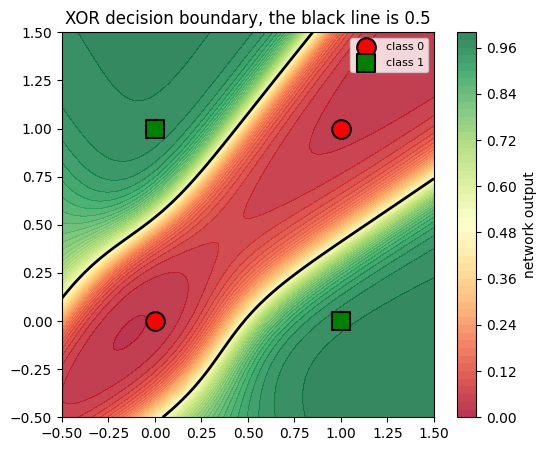

In [13]:
def plot_boundary(net, X, y, title):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    _, out = forward(net, grid)
    out = out.reshape(xx.shape)

    plt.contourf(xx, yy, out, levels=50, cmap='RdYlGn', alpha=0.8)
    plt.colorbar(label="network output")
    plt.contour(xx, yy, out, levels=[0.5], colors='black', linewidths=2)
    for cls, marker, colour in [(0, 'o', 'red'), (1, 's', 'green')]:
        pts = X[y == cls]
        plt.scatter(pts[:,0], pts[:,1], marker=marker, s=180, c=colour,
                    edgecolors='black', linewidths=1.5, label="class " + str(cls))
    plt.title(title)
    plt.legend(fontsize=8)

plt.figure(figsize=(6,5))
plot_boundary(net, X, y_xor, "XOR decision boundary, the black line is 0.5")
plt.show()

The boundary is not a straight line any more, it is bent, and that bend is what a single neuron could never produce.

Each hidden neuron is still drawing only a straight line, the curve comes from combining them. Plotting the four hidden neurons separately shows this clearly.

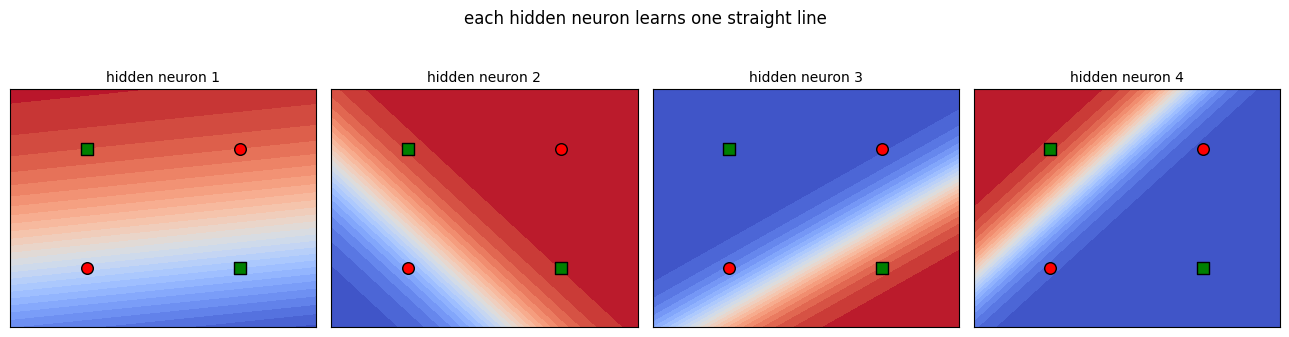

In [14]:
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
H = sigmoid(grid @ net["W1"] + net["b1"])

plt.figure(figsize=(13,3.2))
for j in range(4):
    plt.subplot(1, 4, j+1)
    plt.contourf(xx, yy, H[:, j].reshape(xx.shape), levels=30, cmap='coolwarm')
    for cls, marker, colour in [(0, 'o', 'red'), (1, 's', 'green')]:
        pts = X[y_xor == cls]
        plt.scatter(pts[:,0], pts[:,1], marker=marker, s=70, c=colour, edgecolors='black')
    plt.title("hidden neuron " + str(j+1), fontsize=10)
    plt.xticks([]); plt.yticks([])

plt.suptitle("each hidden neuron learns one straight line", y=1.04)
plt.tight_layout()
plt.show()

**How the boundary forms during the training.** The same XOR network is trained again and the decision boundary is captured at a few points during the run. This shows what the flat part of the loss curve was actually doing.

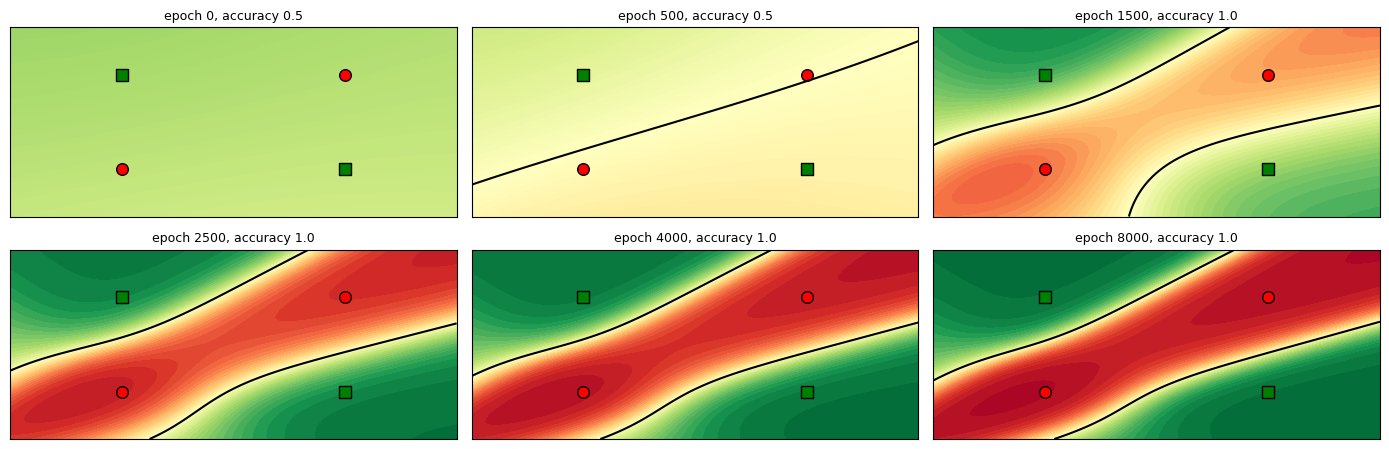

In [15]:
def train_with_snapshots(X, y, snapshot_epochs, n_hidden=4, lr=0.5, seed=1):
    net = init_network(X.shape[1], n_hidden, seed=seed)
    snaps = {}
    total = max(snapshot_epochs)

    for e in range(total + 1):
        if e in snapshot_epochs:
            snaps[e] = {k: v.copy() for k, v in net.items()}
        A1, A2 = forward(net, X)
        net = backward(net, X, y, A1, A2, lr)

    return snaps

points = [0, 500, 1500, 2500, 4000, 8000]
snaps = train_with_snapshots(X, y_xor, points)

xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

plt.figure(figsize=(14,4.6))
for i, e in enumerate(points):
    plt.subplot(2, 3, i+1)
    _, out = forward(snaps[e], grid)
    out = out.reshape(xx.shape)
    plt.contourf(xx, yy, out, levels=40, cmap='RdYlGn', vmin=0, vmax=1)
    plt.contour(xx, yy, out, levels=[0.5], colors='black', linewidths=1.5)
    for cls, marker, colour in [(0, 'o', 'red'), (1, 's', 'green')]:
        pts = X[y_xor == cls]
        plt.scatter(pts[:,0], pts[:,1], marker=marker, s=70, c=colour, edgecolors='black')
    _, o4 = forward(snaps[e], X)
    acc = ((o4.ravel() > 0.5).astype(int) == y_xor).mean()
    plt.title("epoch " + str(e) + ", accuracy " + str(acc), fontsize=9)
    plt.xticks([]); plt.yticks([])

plt.tight_layout()
plt.show()

At epoch 0 the whole plane is almost one flat colour, the network answers nearly the same thing everywhere and the accuracy is 0.5.

At epoch 500 a boundary has appeared but it is still a **single straight line**, so it is behaving exactly like the single neuron of section 3 and the accuracy is still 0.5. This is the flat portion seen in the loss curve.

By epoch 1500 the line has bent into two curves and the accuracy has already reached 1.0. Everything after that, from 2500 to 8000, only sharpens the boundary, the colours become deeper which means the network is becoming more confident about answers it is already getting right.

### 8. Using the network on a real dataset
The logic gates have only four points. Now the same code is used on a proper dataset, `make_moons`, which is two interleaving half circles and cannot be separated by a line.

For this part the loss is changed to binary cross entropy, which is the correct loss for a classification problem and gives a stronger gradient than mse when the prediction is very wrong.

training samples : 280
testing samples  : 120


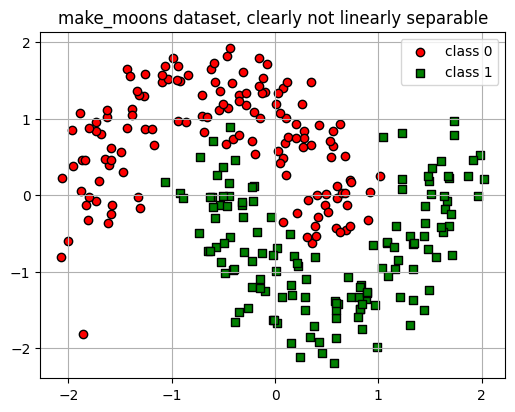

In [16]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Xm, ym = make_moons(n_samples=400, noise=0.20, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    Xm, ym, test_size=0.3, random_state=42, stratify=ym)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

print("training samples :", X_train.shape[0])
print("testing samples  :", X_test.shape[0])

plt.figure(figsize=(6,4.5))
plt.scatter(X_train[y_train==0][:,0], X_train[y_train==0][:,1], c='red', marker='o', edgecolors='k', label="class 0")
plt.scatter(X_train[y_train==1][:,0], X_train[y_train==1][:,1], c='green', marker='s', edgecolors='k', label="class 1")
plt.title("make_moons dataset, clearly not linearly separable")
plt.legend(); plt.grid(True)
plt.show()

In [17]:
def train_network_bce(X, y, n_hidden=8, lr=0.5, epochs=3000, seed=3):
    net = init_network(X.shape[1], n_hidden, seed=seed)
    Y = y.reshape(-1, 1)
    m = len(y)
    history = []

    for e in range(epochs):
        A1, A2 = forward(net, X)

        eps = 1e-9      # so that log(0) never happens
        loss = -np.mean(Y*np.log(A2+eps) + (1-Y)*np.log(1-A2+eps))
        history.append(loss)

        # with cross entropy the sigmoid derivative cancels out, so d2 is just the error
        d2 = (A2 - Y) / m
        d1 = (d2 @ net["W2"].T) * sigmoid_derivative(A1)

        net["W2"] = net["W2"] - lr * (A1.T @ d2)
        net["b2"] = net["b2"] - lr * d2.sum(axis=0)
        net["W1"] = net["W1"] - lr * (X.T @ d1)
        net["b1"] = net["b1"] - lr * d1.sum(axis=0)

    return net, history


def accuracy(net, X, y):
    _, out = forward(net, X)
    return ((out.ravel() > 0.5).astype(int) == y).mean()


net_m, hist_m = train_network_bce(X_train, y_train, n_hidden=8, lr=0.5, epochs=3000)

print("hidden neurons     :", 8)
print("training accuracy  :", round(accuracy(net_m, X_train, y_train), 4))
print("testing accuracy   :", round(accuracy(net_m, X_test, y_test), 4))
print("final loss         :", round(hist_m[-1], 4))

hidden neurons     : 8
training accuracy  : 0.9786
testing accuracy   : 0.9333
final loss         : 0.0796


For comparison the same data is given to a single neuron, which is the same thing as logistic regression.

In [18]:
def train_single_bce(X, y, lr=0.5, epochs=3000, seed=3):
    rng = np.random.default_rng(seed)
    w = rng.normal(0, 0.5, X.shape[1])
    b = 0.0
    for e in range(epochs):
        a = sigmoid(X @ w + b)
        d = (a - y) / len(y)
        w = w - lr * (X.T @ d)
        b = b - lr * d.sum()
    return w, b

w_s, b_s = train_single_bce(X_train, y_train)
acc_tr = ((sigmoid(X_train @ w_s + b_s) > 0.5) == y_train).mean()
acc_te = ((sigmoid(X_test @ w_s + b_s) > 0.5) == y_test).mean()

print("single neuron  ->  train", round(acc_tr,4), " test", round(acc_te,4))
print("hidden layer   ->  train", round(accuracy(net_m, X_train, y_train),4),
      " test", round(accuracy(net_m, X_test, y_test),4))

single neuron  ->  train 0.8107  test 0.875
hidden layer   ->  train 0.9786  test 0.9333


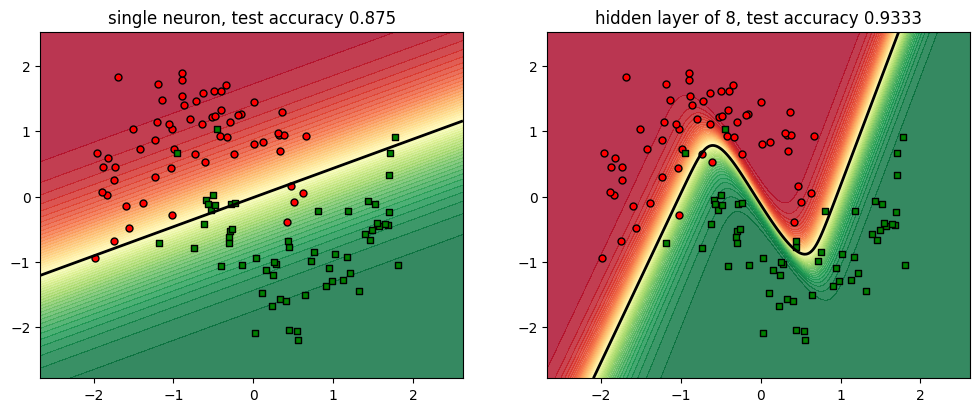

In [19]:
def boundary_grid(X):
    x_min, x_max = X[:,0].min()-0.6, X[:,0].max()+0.6
    y_min, y_max = X[:,1].min()-0.6, X[:,1].max()+0.6
    return np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

xx, yy = boundary_grid(X_train)
grid = np.c_[xx.ravel(), yy.ravel()]

out_single = sigmoid(grid @ w_s + b_s).reshape(xx.shape)
_, out_net = forward(net_m, grid)
out_net = out_net.reshape(xx.shape)

plt.figure(figsize=(12,4.5))

plt.subplot(1,2,1)
plt.contourf(xx, yy, out_single, levels=50, cmap='RdYlGn', alpha=0.8)
plt.contour(xx, yy, out_single, levels=[0.5], colors='black', linewidths=2)
plt.scatter(X_test[y_test==0][:,0], X_test[y_test==0][:,1], c='red', marker='o', edgecolors='k', s=25)
plt.scatter(X_test[y_test==1][:,0], X_test[y_test==1][:,1], c='green', marker='s', edgecolors='k', s=25)
plt.title("single neuron, test accuracy " + str(round(acc_te,4)))

plt.subplot(1,2,2)
plt.contourf(xx, yy, out_net, levels=50, cmap='RdYlGn', alpha=0.8)
plt.contour(xx, yy, out_net, levels=[0.5], colors='black', linewidths=2)
plt.scatter(X_test[y_test==0][:,0], X_test[y_test==0][:,1], c='red', marker='o', edgecolors='k', s=25)
plt.scatter(X_test[y_test==1][:,0], X_test[y_test==1][:,1], c='green', marker='s', edgecolors='k', s=25)
plt.title("hidden layer of 8, test accuracy " + str(round(accuracy(net_m, X_test, y_test),4)))

plt.show()

### 9. Effect of the number of hidden neurons
The same network is trained with a different number of hidden neurons to see how much the capacity matters.

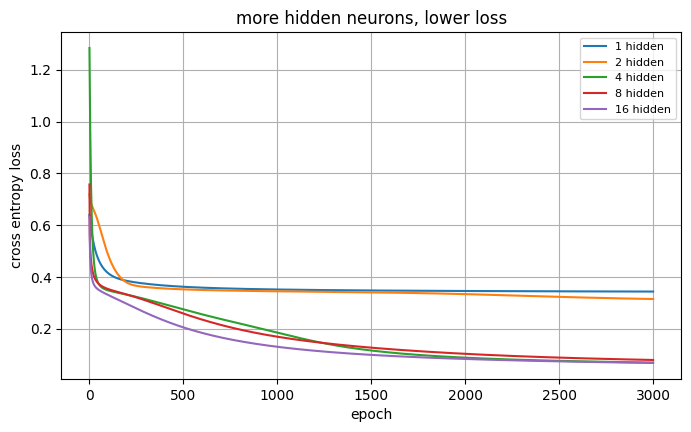

hidden   train acc   test acc   final loss
    1      0.8107     0.8833       0.3438
    2      0.8214     0.8917        0.315
    4      0.9786     0.9333       0.0696
    8      0.9786     0.9333       0.0796
   16      0.9786     0.9417        0.068


In [20]:
results = []

plt.figure(figsize=(8,4.5))
for h in [1, 2, 4, 8, 16]:
    n_h, hist_h = train_network_bce(X_train, y_train, n_hidden=h, lr=0.5, epochs=3000)
    tr = accuracy(n_h, X_train, y_train)
    te = accuracy(n_h, X_test, y_test)
    results.append([h, round(tr,4), round(te,4), round(hist_h[-1],4)])
    plt.plot(hist_h, label=str(h) + " hidden")

plt.xlabel("epoch"); plt.ylabel("cross entropy loss")
plt.title("more hidden neurons, lower loss")
plt.legend(fontsize=8); plt.grid(True)
plt.show()

print("hidden   train acc   test acc   final loss")
for r in results:
    print(str(r[0]).rjust(5), str(r[1]).rjust(11), str(r[2]).rjust(10), str(r[3]).rjust(12))

### 10. Comparing with the library implementation
Finally the same dataset is given to `MLPClassifier` of scikit learn. If the from scratch network is written correctly its accuracy should come close to the library one.

In [21]:
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings("ignore")

sk = MLPClassifier(hidden_layer_sizes=(8,), activation='relu', solver='adam',
                   max_iter=3000, random_state=42)
sk.fit(X_train, y_train)

print("                  train acc   test acc")
print("my network     :", round(accuracy(net_m, X_train, y_train),4), "     ",
      round(accuracy(net_m, X_test, y_test),4))
print("sklearn MLP    :", round(sk.score(X_train, y_train),4), "     ",
      round(sk.score(X_test, y_test),4))
print()
print("sklearn stopped after", sk.n_iter_, "iterations")

                  train acc   test acc
my network     : 0.9786       0.9333
sklearn MLP    : 0.9643       0.9583

sklearn stopped after 1794 iterations


### 11. Result

A neural network was implemented from scratch using only numpy and was tested on the logic gates and on the make_moons dataset.

**Logic gates with a single neuron**

| Gate | Accuracy | Final loss |
|---|---|---|
| AND | 1.00 | 0.0021 |
| OR | 1.00 | 0.0011 |
| XOR | 0.50 | 0.2500 |

**XOR after adding a hidden layer of 4 neurons**

| Input | Network output | Predicted | Expected |
|---|---|---|---|
| 0, 0 | 0.0222 | 0 | 0 |
| 0, 1 | 0.9719 | 1 | 1 |
| 1, 0 | 0.9738 | 1 | 1 |
| 1, 1 | 0.0342 | 0 | 0 |

Accuracy 1.00 and the final loss came down to 0.000786.

**make_moons dataset, 280 training and 120 testing samples**

| Model | Train accuracy | Test accuracy |
|---|---|---|
| Single neuron | 0.8107 | 0.8750 |
| Hidden layer of 8 | 0.9786 | 0.9333 |
| sklearn MLPClassifier | 0.9643 | 0.9583 |

**Effect of the hidden layer size**

| Hidden neurons | Train acc | Test acc | Final loss |
|---|---|---|---|
| 1 | 0.8107 | 0.8833 | 0.3438 |
| 2 | 0.8214 | 0.8917 | 0.3150 |
| 4 | 0.9786 | 0.9333 | 0.0696 |
| 8 | 0.9786 | 0.9333 | 0.0796 |
| 16 | 0.9786 | 0.9417 | 0.0680 |

### 12. Conclusion

A simple artificial neural network was implemented in python without using any machine learning library, and every part of it, the forward pass, the loss, the backpropagation and the gradient descent update, was written manually.

The experiment shows very clearly why the hidden layer exists. A single neuron computes a weighted sum followed by an activation, which can only place one straight boundary in the input space, so it learnt AND and OR perfectly but on XOR it stopped at an accuracy of 0.5 with the loss stuck at 0.25, which means it was returning nearly 0.5 for every input. After putting a hidden layer of four neurons in between, the same problem was solved completely with the outputs reaching 0.02 and 0.97. The plot of the individual hidden neurons explains the reason, each hidden neuron still draws only a straight line, and the curved boundary seen at the output is produced by combining these straight lines through the second layer.

The same behaviour was observed on a real dataset. On make_moons the single neuron reached a test accuracy of 0.8750 because it could only cut the two half circles with one straight line, while the network with a hidden layer of eight neurons reached 0.9333 by bending the boundary around the shape of the data.

The study of the hidden layer size shows that the capacity of the network has to match the problem. With one or two hidden neurons the network stayed near the accuracy of the single neuron with a loss above 0.31, and from four neurons onwards the loss dropped to about 0.07 and the accuracy jumped, after which adding more neurons gave very little improvement.

One honest observation is that the network written here reached a slightly higher training accuracy than the library model, 0.9786 against 0.9643, but a lower testing accuracy, 0.9333 against 0.9583. This means the manual network has fitted the training data a little more than required, and the library model generalises better because it uses the adam optimiser along with an internal validation check for early stopping, neither of which is present in the plain gradient descent written here.

It is concluded that a neural network is nothing more than repeated multiplication by weights followed by a non linear activation, with backpropagation deciding how the weights should change. The from scratch implementation reached an accuracy comparable to the library implementation, which confirms that the mathematics has been implemented correctly, and the difference in generalisation shows the value of the optimisation techniques which the standard libraries add on top of the basic algorithm.